<a href="https://colab.research.google.com/github/csanudo/AIBridge_bootcamp/blob/main/Lab_4_Demo_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Lab 4 Demo**
### Please make a copy of this!

## Goals: Evaluating Models and Handling Dataset Problems

1) We will take a look at model performance using confusion matrices;
2) We will practice handling dataset problems such as categorical data, missing data, outliers, and imbalancedness.

We will continue to use the iris dataset at https://archive.ics.uci.edu/dataset/53/iris.

You will then run through these same step on the wine quality dataset in the lab 4 assignment.

## Evaluating Models

In [1]:
# import dependencies
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# download data
!curl -O https://archive.ics.uci.edu/static/public/53/iris.zip
!unzip iris.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  3738    0  3738    0     0   9980      0 --:--:-- --:--:-- --:--:--  9994
Archive:  iris.zip
  inflating: Index                   
  inflating: bezdekIris.data         
  inflating: iris.data               
  inflating: iris.names              


In [3]:
# loading the iris dataset
df = pd.read_csv('iris.data', header=None, names=['sepal length', 'sepal width', 'petal length', 'petal width', 'class'])
df.head()

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
# collect numerical data
X = df[['sepal length', 'sepal width', 'petal length', 'petal width']]
X.head()

,sepal length,sepal width,petal length,petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
# collect class labels
classes = df['class'].unique()
y = df['class'].values

print(classes)
print(y[:10])

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
['Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa']


In [6]:
# separate the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

In [7]:
# we will create 3 predictors and compare their confusion matrix
# each model is a function that takes in the four numerical features
# and returns a predicted class label

# model 1: random guess
def random_model(X):
    return np.random.choice(classes, size=len(X))

In [8]:
# model 2: biased guess towards the most common class
# returns the most common class 90% of the time, and a random class 10% of the time
most_common_class = df['class'].mode()[0]

def biased_model(X):
    predictions = []
    for _ in range(len(X)):
        if np.random.rand() < 0.9:
            predictions.append(most_common_class)
        else:
            predictions.append(np.random.choice(classes))
    return np.array(predictions)

In [9]:
# model 3: logistic regression model

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

def logistic_model(X):
    return model.predict(X)

In [10]:
# collect predictions from each model
y_random = random_model(X_test)
y_biased = biased_model(X_test)
y_logistic = logistic_model(X_test)

print(y_test[:5])
print(y_random[:5])
print(y_biased[:5])
print(y_logistic[:5])

['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor']
['Iris-setosa' 'Iris-virginica' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor']
['Iris-setosa' 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa']
['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor']


In [21]:
# a function to plot confusion matrix without seaborn
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels = classes)
    cm = cm / cm.sum(axis=1)[:, np.newaxis]
    print(cm)
    sns.heatmap(cm, annot=True,
                xticklabels=classes,
                yticklabels=classes,
                cmap='Blues',
                vmin=0,
                vmax=1)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

[[0.27586207 0.31034483 0.4137931 ]
 [0.34782609 0.43478261 0.2173913 ]
 [0.30434783 0.26086957 0.43478261]]


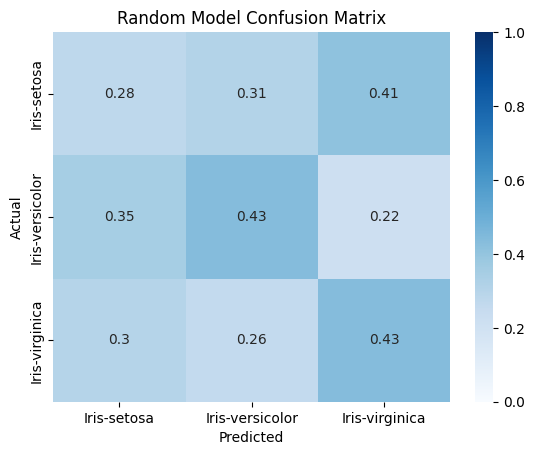

In [22]:
plot_confusion_matrix(y_test, y_random, 'Random Model Confusion Matrix')

[[0.96551724 0.         0.03448276]
 [0.95652174 0.         0.04347826]
 [0.91304348 0.04347826 0.04347826]]


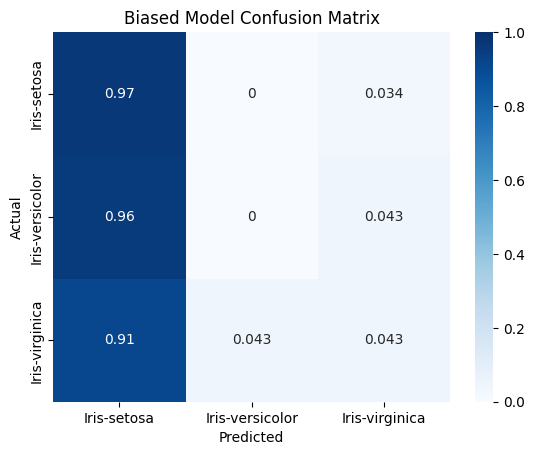

In [23]:
plot_confusion_matrix(y_test, y_biased, 'Biased Model Confusion Matrix')

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


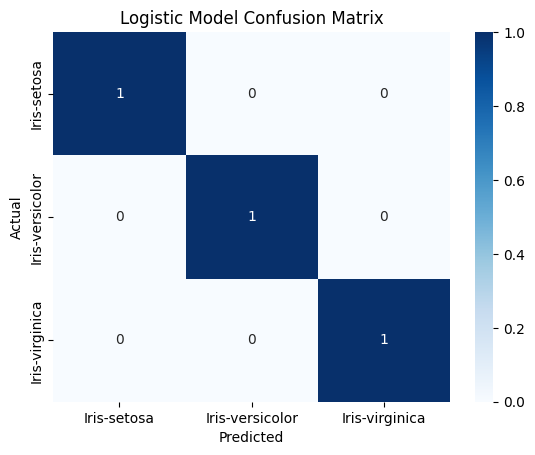

In [24]:
plot_confusion_matrix(y_test, y_logistic, 'Logistic Model Confusion Matrix')

## Data Issues

In [29]:
import requests
!wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1Zg-iYmg5VN_ZaixdXcXfuyF-1zTDymFk' -O iris_problem.csv

--2026-08-04 22:15:22--  https://drive.google.com/uc?export=download&id=1Zg-iYmg5VN_ZaixdXcXfuyF-1zTDymFk
Resolving drive.google.com (drive.google.com)... 142.251.184.138, 142.251.184.139, 142.251.184.100, ...
Connecting to drive.google.com (drive.google.com)|142.251.184.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1Zg-iYmg5VN_ZaixdXcXfuyF-1zTDymFk&export=download [following]
--2026-08-04 22:15:22--  https://drive.usercontent.google.com/download?id=1Zg-iYmg5VN_ZaixdXcXfuyF-1zTDymFk&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.183.132, 2607:f8b0:4001:c64::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.183.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3368 (3.3K) [application/octet-stream]
Saving to: ‘iris_problem.csv’

iris_problem.csv    100%[===================>]   3.29K  --.

In [30]:
# loading the dataset
df_problem = pd.read_csv('iris_problem.csv')
df_problem

,sepal length,sepal width,petal length,petal width,class
0,4.7,3.2,small,0.2,Iris-setosa
1,NaN,3.1,small,0.2,Iris-setosa
2,5.4,3.9,small,0.4,Iris-setosa
3,4.6,3.4,small,0.3,Iris-setosa
4,4.9,3.1,small,0.1,Iris-setosa
...,...,...,...,...,...
95,6.9,-1.0,large,2.1,Iris-virginica
96,6.7,3.1,large,2.4,Iris-virginica
97,6.8,-1.0,large,2.3,Iris-virginica
98,6.5,-1.0,large,2.0,Iris-virginica


In [32]:
# check missing data
df_problem.isna().sum()


,0
sepal length,12
sepal width,0
petal length,0
petal width,0
class,0


In [ ]:
# fill missing sepal length with average
median_sepal_length = df_problem['sepal length'].median()
df_problem['sepal length'] = df_problem['sepal length'].fillna(median_sepal_length)

In [ ]:
# check distribution of sepal width


In [35]:
# fill sepal width outliers with average
median_sepal_width = df_problem.loc[df_problem['sepal width'] > 0, "sepal width"].median()

df_problem.loc[df_problem['sepal width'] < 0, "sepal width"] = median_sepal_width

In [37]:
# check categorical petal length
df_problem['petal length'].value_counts()

,count
petal length,
medium,54
small,23
large,23


In [38]:
# convert categorical data to one-hot encoding
df_problem = pd.get_dummies(df_problem, columns=['petal length'])
df_problem

,sepal length,sepal width,petal width,class,petal length_large,petal length_medium,petal length_small
0,4.7,3.2,0.2,Iris-setosa,False,False,True
1,NaN,3.1,0.2,Iris-setosa,False,False,True
2,5.4,3.9,0.4,Iris-setosa,False,False,True
3,4.6,3.4,0.3,Iris-setosa,False,False,True
4,4.9,3.1,0.1,Iris-setosa,False,False,True
...,...,...,...,...,...,...,...
95,6.9,3.0,2.1,Iris-virginica,True,False,False
96,6.7,3.1,2.4,Iris-virginica,True,False,False
97,6.8,3.0,2.3,Iris-virginica,True,False,False
98,6.5,3.0,2.0,Iris-virginica,True,False,False


In [39]:
# check class distribution
df_problem['class'].value_counts()

,count
class,
Iris-versicolor,50
Iris-virginica,27
Iris-setosa,23


In [42]:
# downsampling the versicolor class
min_class_size = df_problem['class'].value_counts().min()
min_class_size

23

In [43]:
# downsampling to min_class_size
df_downsampled = []
for class_name in classes:
  rows = df_problem[df_problem['class'] == class_name]
  downsampled_rows = rows.sample(n=min_class_size)
  df_downsampled.append(downsampled_rows)

df_downsampled = pd.concat(df_downsampled)
df_downsampled

,sepal length,sepal width,petal width,class,petal length_large,petal length_medium,petal length_small
16,5.1,3.4,0.2,Iris-setosa,False,False,True
19,5.0,3.5,0.6,Iris-setosa,False,False,True
11,5.4,3.4,0.4,Iris-setosa,False,False,True
2,5.4,3.9,0.4,Iris-setosa,False,False,True
8,NaN,3.0,0.2,Iris-setosa,False,False,True
...,...,...,...,...,...,...,...
74,5.8,2.7,1.9,Iris-virginica,True,False,False
94,6.4,3.1,1.8,Iris-virginica,True,False,False
93,6.3,3.4,2.4,Iris-virginica,True,False,False
96,6.7,3.1,2.4,Iris-virginica,True,False,False


In [44]:
df_downsampled['class'].value_counts()

,count
class,
Iris-setosa,23
Iris-versicolor,23
Iris-virginica,23
